# Permutation Feature Importance (PFI)

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes, load_iris
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import accuracy_score, r2_score

## Loading and training the model

In [2]:
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12, shuffle=True)

rf = RandomForestClassifier(n_estimators=3, random_state=32).fit(X_train, y_train)

In [3]:
print(accuracy_score(rf.predict(X_train), y_train))
print(accuracy_score(rf.predict(X_test), y_test))

0.9904761904761905
0.9555555555555556


In [6]:
original_error_train = 1 - accuracy_score(rf.predict(X_train), y_train)
original_error_test = 1 - accuracy_score(rf.predict(X_test), y_test)

In [7]:
original_error_train, original_error_test

(0.1333333333333333, 0.1333333333333333)

## Calculating the permutation scores

In [15]:
n_steps = 10

feature_values = {}

for feature in range(X.shape[1]):
    errors_permuted_train = []
    errors_permuted_test = []
    
    for step in range(n_steps):
        # We grab the data again because the np.random.shuffle function shuffles in place
        X, y = load_iris(return_X_y=True)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12, shuffle=True)

        np.random.shuffle(X_train[:, feature])
        np.random.shuffle(X_test[:, feature])
        
        errors_permuted_train.append(1 - accuracy_score(rf.predict(X_train), y_train))
        errors_permuted_test.append(1 - accuracy_score(rf.predict(X_test), y_test))
        
    feature_values[f'{feature}_train'] = errors_permuted_train
    feature_values[f'{feature}_test'] = errors_permuted_test

In [16]:
PFI = pd.DataFrame()
for feature in feature_values:
    if 'train' in feature:
        aux = feature_values[feature] / original_error_train
        fold = 'train'
    elif 'test' in feature:
        aux = feature_values[feature] / original_error_test
        fold = 'test'
    
    PFI = PFI.append({
        'feature': feature.replace(f'_{fold}', ''),
        'fold': fold,
        'mean':np.mean(aux),
        'std':np.std(aux),
    }, ignore_index=True)
    
PFI = PFI.pivot(index='feature', columns='fold', values=['mean', 'std']).reset_index().sort_values(('mean', 'test'), ascending=False)

In [17]:
PFI

feature      mean                 std          
fold              test     train      test     train
2          2  2.150000  2.607143  0.485627  0.235281
3          3  0.966667  1.150000  0.244949  0.181968
0          0  0.383333  0.150000  0.076376  0.038465
1          1  0.233333  0.092857  0.081650  0.032733

In [19]:
PFI[('mean', 'train')]

2    2.607143
3    1.150000
0    0.150000
1    0.092857
Name: (mean, train), dtype: float64

Text(0.5, 0, 'Feature')

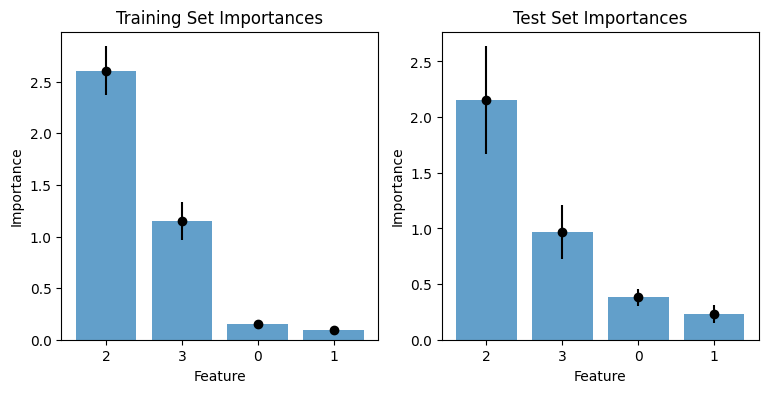

In [38]:
fig, axs = plt.subplots(1, 2, figsize=(9,4), sharex=True)

axs[0].bar(PFI['feature'], PFI[('mean', 'train')], alpha=0.7)
axs[0].errorbar(PFI['feature'], PFI[('mean', 'train')], yerr=PFI[('std', 'train')], fmt='o', ecolor='black', color='black')
axs[0].set_title('Training Set Importances')
axs[0].set_ylabel('Importance')
axs[0].set_xlabel('Feature')

axs[1].bar(PFI['feature'], PFI[('mean', 'test')], alpha=0.7)
axs[1].errorbar(PFI['feature'], PFI[('mean', 'test')], yerr=PFI[('std', 'test')], fmt='o', ecolor='black', color='black')
axs[1].set_title('Test Set Importances')
axs[1].set_ylabel('Importance')
axs[1].set_xlabel('Feature')